# Single-Feature Clustering and Robustness Sweep — 7B

**Purpose:**
1. Run a single-feature sweep over all L1 features to identify the best discriminating feature.
2. Run a robustness sweep on that single best feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the single feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why single feature only:**
The single best feature (core_power.throttle__mean_rate) is the primary result.
The robustness sweep on this feature alone isolates whether the signal is stable
across prompt subsets without the noise introduced by greedy multi-feature selection.

## §1 — Imports and configuration

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / '70b'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['1', '2', '3','4','5','6', '7']

# ── L1 indicators ──────────────────────────────────────────────────────────────
L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')

Configuration OK
  Runs         : ['1', '2', '3', '4', '5', '6', '7']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [3]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'independent{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')

Loaded 7 runs: ['1', '2', '3', '4', '5', '6', '7']
  Total trials : 280
  Emotional    : 140
  Neutral      : 140


## §3 — Select L1 features

In [4]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')

L1 features available: 30


## §4 — Single-feature sweep: find the best feature

In [5]:
def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
records = []
for col in X_l1.columns:
    acc, ari = kmeans_acc_ari(X_l1[[col]].values, y_true, n_init=N_INIT, seed=RAND_SEED)
    records.append({'feature': col, 'indicator': indicator_of(col),
                    'metric': col.split('__')[-1], 'accuracy': acc, 'ari': ari})

sf = pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)

BEST_FEATURE = sf.iloc[0]['feature']
BEST_ACC     = sf.iloc[0]['accuracy']
BEST_ARI     = sf.iloc[0]['ari']

print(f'Best single feature : {BEST_FEATURE}')
print(f'  Accuracy          : {BEST_ACC:.4f}')
print(f'  ARI               : {BEST_ARI:.4f}')
print()
print('Top 5:')
print(sf[['feature','accuracy','ari']].head(5).to_string(index=False))

Best single feature : core_power.throttle__mean_rate
  Accuracy          : 0.5714
  ARI               : 0.0169

Top 5:
                              feature  accuracy      ari
       core_power.throttle__mean_rate  0.571429 0.016902
      core_power.throttle__burst_rate  0.546429 0.005153
            hat_TLB__burst_clustering  0.539286 0.003982
core_power.throttle__burst_clustering  0.532143 0.002345
              tlb:tlb_flush__variance  0.532143 0.000727


## §5 — Robustness sweep on the best single feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials (across all runs) matching those prompt indices.
- Run k-means on the single best feature.
- Record accuracy and ARI.

This tests whether the signal in the best feature is stable across
different prompt subsets, without the inflation from greedy feature selection.

In [6]:
# All prompt indices per condition
emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')

Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]
Neutral prompt indices   (20):   [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(30), np.int64(31)]


In [7]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        sub = df_all[mask].copy()

        X_sub = sub[[BEST_FEATURE]].fillna(sub[[BEST_FEATURE]].median()).values
        y_sub = sub['label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)

  x=22  total= 154  mean_acc=0.5610  ±0.0391  mean_ARI=0.0147
  x=24  total= 168  mean_acc=0.5720  ±0.0382  mean_ARI=0.0208
  x=26  total= 182  mean_acc=0.5764  ±0.0302  mean_ARI=0.0216
  x=28  total= 196  mean_acc=0.5727  ±0.0268  mean_ARI=0.0190
  x=30  total= 210  mean_acc=0.5752  ±0.0291  mean_ARI=0.0214
  x=32  total= 224  mean_acc=0.5696  ±0.0200  mean_ARI=0.0166
  x=34  total= 238  mean_acc=0.5731  ±0.0226  mean_ARI=0.0193
  x=36  total= 252  mean_acc=0.5760  ±0.0185  mean_ARI=0.0206
  x=38  total= 266  mean_acc=0.5763  ±0.0117  mean_ARI=0.0202
  x=40  total= 280  mean_acc=0.5714  ±0.0000  mean_ARI=0.0169


## §6 — Plot

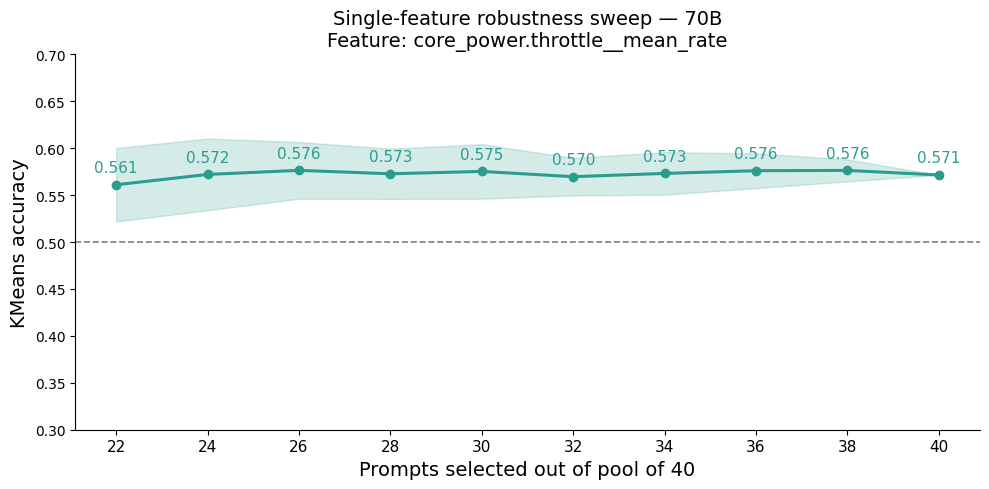

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_70b.png


In [8]:
COLOR = '#2a9d8f'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=14)
ax.set_ylabel('KMeans accuracy', fontsize=14)
ax.set_title(
    f'Single-feature robustness sweep — 70B\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=14
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_70b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## §7 — Summary table

In [9]:
print('Single-feature robustness sweep — 7B')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print(f'Chance baseline: 0.5000')

Single-feature robustness sweep — 7B
Best feature: core_power.throttle__mean_rate
Full-dataset accuracy (x=40): 0.5714

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     154     0.5610   0.0391     0.0147   0.0231
    24     168     0.5720   0.0382     0.0208   0.0219
    26     182     0.5764   0.0302     0.0216   0.0204
    28     196     0.5727   0.0268     0.0190   0.0140
    30     210     0.5752   0.0291     0.0214   0.0202
    32     224     0.5696   0.0200     0.0166   0.0105
    34     238     0.5731   0.0226     0.0193   0.0139
    36     252     0.5760   0.0185     0.0206   0.0117
    38     266     0.5763   0.0117     0.0202   0.0073
    40     280     0.5714   0.0000     0.0169   0.0000

Chance baseline: 0.5000


In [10]:
for cond in ['emotional', 'neutral']:
    vals = df_all[df_all.condition == cond][BEST_FEATURE].dropna()
    print(f'{cond:10s}  n={len(vals):4d}  mean={vals.mean():.2f}  median={vals.median():.2f}  std={vals.std():.2f}')

emotional   n= 140  mean=95760.30  median=97201.63  std=27211.66
neutral     n= 140  mean=89471.58  median=87995.95  std=21524.01


In [11]:
FEATURE = 'core_power.throttle__mean_rate'

for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond].copy().reset_index(drop=True)

    # Pseudo ground truth: rank trials by index, assign first half label 0, second half label 1
    # This guarantees exactly 50/50 split regardless of prompt index distribution
    n = len(sub)
    pseudo = np.zeros(n, dtype=int)
    pseudo[n // 2:] = 1
    # Shuffle by prompt index to avoid positional bias
    order = sub['prompt_index'].argsort().values
    sub = sub.iloc[order].reset_index(drop=True)
    sub['pseudo_label'] = pseudo

    X = sub[[FEATURE]].fillna(sub[[FEATURE]].median()).values
    y = sub['pseudo_label'].values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=N_INIT, random_state=RAND_SEED)
    pred = km.fit_predict(Xs)

    cm = confusion_matrix(y, pred)
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)

    print(f'{cond:10s}  n={len(sub):4d}  label_0={( y==0).sum()}  label_1={(y==1).sum()}')
    print(f'  acc={acc:.4f}  ARI={ari:.4f}')
    print(f'  Expected: acc ≈ 0.50, ARI ≈ 0.00')
    print()

emotional   n= 140  label_0=70  label_1=70
  acc=0.5929  ARI=0.0275
  Expected: acc ≈ 0.50, ARI ≈ 0.00

neutral     n= 140  label_0=70  label_1=70
  acc=0.5214  ARI=-0.0051
  Expected: acc ≈ 0.50, ARI ≈ 0.00



1. Mean throttle rate by prompt index
 prompt_index condition  core_power.throttle__mean_rate
            0 emotional                    91753.350606
            1 emotional                    64448.190156
            2 emotional                    83250.808384
            3   neutral                    88184.394868
            4   neutral                    89397.046052
            5   neutral                    58981.813704
            6   neutral                    98902.762227
            7 emotional                    80017.977589
            8 emotional                    63057.942172
            9   neutral                   107316.646679
           10   neutral                    57236.352186
           11   neutral                    81671.359780
           12   neutral                    88334.963042
           13 emotional                   126153.880473
           14 emotional                   109437.988786
           15   neutral                   100184.765169
          

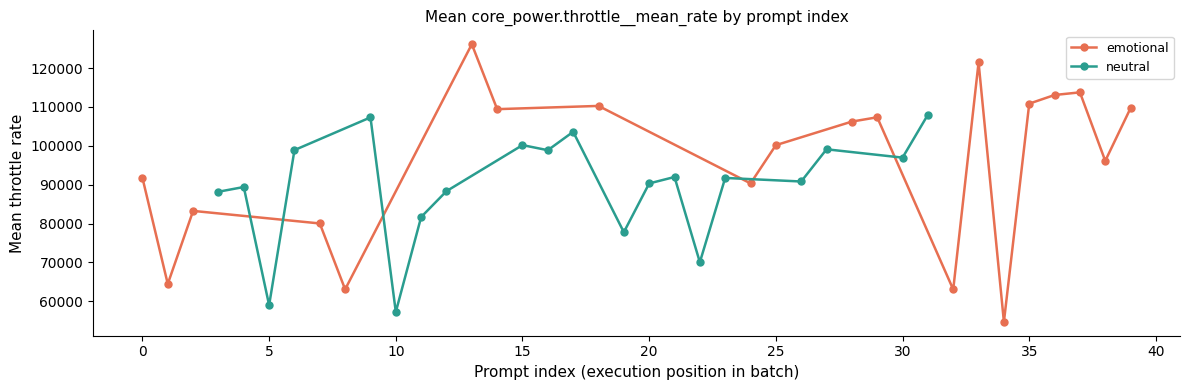

emotional   Spearman r=0.2343  p=0.0053
neutral     Spearman r=0.1836  p=0.0299

2. Mean throttle rate by run
run condition  core_power.throttle__mean_rate
  1 emotional                    94628.433780
  1   neutral                    85756.986804
  2 emotional                    90581.213905
  2   neutral                    90026.069378
  3 emotional                    92189.560010
  3   neutral                    91891.761934
  4 emotional                   102849.900242
  4   neutral                    88226.737079
  5 emotional                    99196.811885
  5   neutral                    90756.399042
  6 emotional                    93849.718695
  6   neutral                    91803.755846
  7 emotional                    97026.471366
  7   neutral                    87839.373017


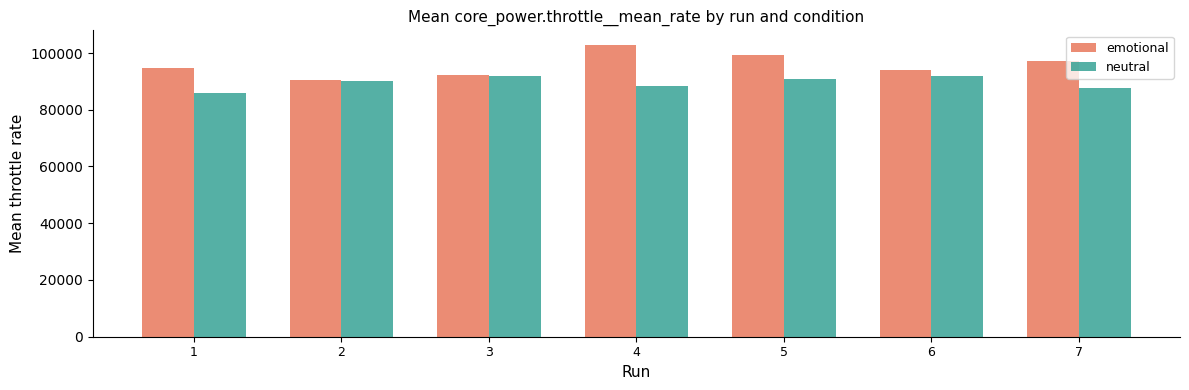

Per-run Mann-Whitney U test (emotional vs neutral):
  Run           U           p     direction
---------------------------------------------
    1       249.0      0.1895   ↑ emotional
    2       198.0      0.9676   ↑ emotional
    3       202.0      0.9676   ↑ emotional
    4       260.0      0.1075   ↑ emotional
    5       246.0      0.2184   ↑ emotional
    6       204.0      0.9246   ↑ emotional
    7       242.0      0.2616   ↑ emotional

3. Partial correlation: condition vs throttle, controlling for prompt index
Raw correlation       (condition vs throttle):              r=0.1276  p=0.0328
Partial correlation   (after removing prompt index effect): r=0.0609  p=0.3101

4. Early (indices 0-19) vs late (indices 20-39) throttle rates
emotional   early mean=91049.03 (n=56)  late mean=98901.15 (n=84)  MWU p=0.1170
neutral     early mean=87538.83 (n=84)  late mean=92370.72 (n=56)  MWU p=0.2150

Prompt index distribution per condition:
  emotional  early indices: [np.int64(0), np.int6

In [13]:
import scipy.stats as stats

FEATURE = 'core_power.throttle__mean_rate'

# ── 1. Mean throttle rate by prompt index position ─────────────────────────────
print("=" * 60)
print("1. Mean throttle rate by prompt index")
print("=" * 60)
by_prompt = df_all.groupby(['prompt_index', 'condition'])[FEATURE].mean().reset_index()
print(by_prompt.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    sub = by_prompt[by_prompt.condition == cond].sort_values('prompt_index')
    ax.plot(sub['prompt_index'], sub[FEATURE], marker='o', lw=1.8,
            color=color, label=cond, markersize=5)
ax.set_xlabel('Prompt index (execution position in batch)', fontsize=11)
ax.set_ylabel('Mean throttle rate', fontsize=11)
ax.set_title('Mean core_power.throttle__mean_rate by prompt index', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_by_prompt_index.png', dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlation between prompt index and throttle rate (all trials)
for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond]
    r, p = stats.spearmanr(sub['prompt_index'], sub[FEATURE].fillna(sub[FEATURE].median()))
    print(f'{cond:10s}  Spearman r={r:.4f}  p={p:.4f}')

print()

# ── 2. Mean throttle rate by run ───────────────────────────────────────────────
print("=" * 60)
print("2. Mean throttle rate by run")
print("=" * 60)
by_run = df_all.groupby(['run', 'condition'])[FEATURE].mean().reset_index()
print(by_run.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
runs_sorted = sorted(df_all['run'].unique())
x = np.arange(len(runs_sorted))
width = 0.35
for i, (cond, color) in enumerate([('emotional', '#e76f51'), ('neutral', '#2a9d8f')]):
    vals = [by_run[(by_run.run == r) & (by_run.condition == cond)][FEATURE].values[0]
            if len(by_run[(by_run.run == r) & (by_run.condition == cond)]) > 0
            else np.nan for r in runs_sorted]
    ax.bar(x + i * width, vals, width, label=cond, color=color, alpha=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(runs_sorted, fontsize=9)
ax.set_xlabel('Run', fontsize=11)
ax.set_ylabel('Mean throttle rate', fontsize=11)
ax.set_title('Mean core_power.throttle__mean_rate by run and condition', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_by_run.png', dpi=150, bbox_inches='tight')
plt.show()

# Mann-Whitney U between emotional and neutral per run
print("Per-run Mann-Whitney U test (emotional vs neutral):")
print(f"{'Run':>5}  {'U':>10}  {'p':>10}  {'direction':>12}")
print("-" * 45)
for run in runs_sorted:
    e = df_all[(df_all.run == run) & (df_all.condition == 'emotional')][FEATURE].dropna()
    n = df_all[(df_all.run == run) & (df_all.condition == 'neutral')][FEATURE].dropna()
    if len(e) > 1 and len(n) > 1:
        u, p = stats.mannwhitneyu(e, n, alternative='two-sided')
        direction = '↑ emotional' if e.mean() > n.mean() else '↑ neutral'
        print(f'{run:>5}  {u:>10.1f}  {p:>10.4f}  {direction:>12}')
print()

# ── 3. Partial correlation controlling for prompt index ────────────────────────
print("=" * 60)
print("3. Partial correlation: condition vs throttle, controlling for prompt index")
print("=" * 60)
from scipy.stats import pearsonr

df_tmp = df_all[['condition', 'prompt_index', FEATURE]].dropna().copy()
df_tmp['cond_binary'] = (df_tmp['condition'] == 'emotional').astype(float)

# Residualise both variables against prompt index
def residualise(y, x):
    slope, intercept, _, _, _ = stats.linregress(x, y)
    return y - (slope * x + intercept)

x = df_tmp['prompt_index'].values.astype(float)
y_cond     = df_tmp['cond_binary'].values
y_throttle = df_tmp[FEATURE].values

res_cond     = residualise(y_cond,     x)
res_throttle = residualise(y_throttle, x)

r_raw,     p_raw     = pearsonr(y_cond, y_throttle)
r_partial, p_partial = pearsonr(res_cond, res_throttle)

print(f'Raw correlation       (condition vs throttle):              r={r_raw:.4f}  p={p_raw:.4f}')
print(f'Partial correlation   (after removing prompt index effect): r={r_partial:.4f}  p={p_partial:.4f}')
print()

# ── 4. Early (0-19) vs late (20-39) prompt positions ──────────────────────────
print("=" * 60)
print("4. Early (indices 0-19) vs late (indices 20-39) throttle rates")
print("=" * 60)
for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond]
    early = sub[sub['prompt_index'] <= 19][FEATURE].dropna()
    late  = sub[sub['prompt_index'] >  19][FEATURE].dropna()
    u, p  = stats.mannwhitneyu(early, late, alternative='two-sided')
    print(f'{cond:10s}  early mean={early.mean():.2f} (n={len(early)})  '
          f'late mean={late.mean():.2f} (n={len(late)})  '
          f'MWU p={p:.4f}')

print()
early_e = df_all[(df_all.condition == 'emotional') & (df_all.prompt_index <= 19)][FEATURE].dropna()
late_e  = df_all[(df_all.condition == 'emotional') & (df_all.prompt_index >  19)][FEATURE].dropna()
early_n = df_all[(df_all.condition == 'neutral')   & (df_all.prompt_index <= 19)][FEATURE].dropna()
late_n  = df_all[(df_all.condition == 'neutral')   & (df_all.prompt_index >  19)][FEATURE].dropna()

print("Prompt index distribution per condition:")
print(f"  emotional  early indices: {sorted(df_all[(df_all.condition=='emotional') & (df_all.prompt_index<=19)]['prompt_index'].unique())}")
print(f"  emotional  late  indices: {sorted(df_all[(df_all.condition=='emotional') & (df_all.prompt_index> 19)]['prompt_index'].unique())}")
print(f"  neutral    early indices: {sorted(df_all[(df_all.condition=='neutral')   & (df_all.prompt_index<=19)]['prompt_index'].unique())}")
print(f"  neutral    late  indices: {sorted(df_all[(df_all.condition=='neutral')   & (df_all.prompt_index> 19)]['prompt_index'].unique())}")

Linear fit: throttle = 555.81 * prompt_index + 81777.60
Residual mean: -0.0000  (should be ~0)
Residual std:  23839.71

Clustering on position-residualised throttle:
  acc=0.5250  ARI=-0.0011
  Chance: acc=0.5000  ARI=0.0000

emotional   mean=1393.55  median=1580.57  std=26335.62
neutral     mean=-1393.55  median=-3089.00  std=21054.11


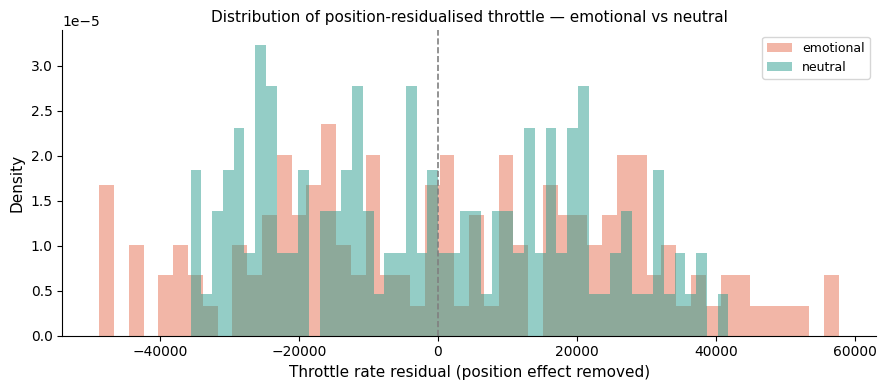

In [15]:
from scipy.stats import linregress

FEATURE = 'core_power.throttle__mean_rate'

# ── Residualise throttle against prompt index ──────────────────────────────────
df_res = df_all[['condition', 'prompt_index', 'run', FEATURE]].dropna().copy()

x = df_res['prompt_index'].values.astype(float)
y = df_res[FEATURE].values.astype(float)

slope, intercept, _, _, _ = linregress(x, y)
df_res['throttle_residual'] = y - (slope * x + intercept)

print(f'Linear fit: throttle = {slope:.2f} * prompt_index + {intercept:.2f}')
print(f'Residual mean: {df_res.throttle_residual.mean():.4f}  (should be ~0)')
print(f'Residual std:  {df_res.throttle_residual.std():.2f}')
print()

# ── K-means on residuals ───────────────────────────────────────────────────────
y_true = (df_res['condition'] == 'emotional').astype(int).values
X = df_res[['throttle_residual']].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
km = KMeans(n_clusters=2, n_init=N_INIT, random_state=RAND_SEED)
pred = km.fit_predict(Xs)

cm = confusion_matrix(y_true, pred)
acc = max(
    (cm[0,0] + cm[1,1]) / cm.sum(),
    (cm[0,1] + cm[1,0]) / cm.sum()
)
ari = adjusted_rand_score(y_true, pred)

print(f'Clustering on position-residualised throttle:')
print(f'  acc={acc:.4f}  ARI={ari:.4f}')
print(f'  Chance: acc=0.5000  ARI=0.0000')
print()

# ── Distribution of residuals per condition ────────────────────────────────────
for cond in ['emotional', 'neutral']:
    vals = df_res[df_res.condition == cond]['throttle_residual']
    print(f'{cond:10s}  mean={vals.mean():.2f}  median={vals.median():.2f}  std={vals.std():.2f}')

# ── Plot residual distributions ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    vals = df_res[df_res.condition == cond]['throttle_residual']
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cond, density=True)
ax.axvline(0, color='grey', lw=1.2, ls='--')
ax.set_xlabel('Throttle rate residual (position effect removed)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of position-residualised throttle — emotional vs neutral', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()